# Import of relevant packages

In [1]:
# -*- coding: utf-8 -*-

import smtplib
import os
import tika
import sys

from tika import parser
from os.path import basename
from PyPDF2 import PdfReader, PdfWriter

from read_contacts import get_contacts, read_template, get_filenames

from google.auth.transport.requests import Request
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.application import MIMEApplication

/Users/carlahugod/Desktop/Regnskab/.venv/lib/python3.13/site-packages/tika/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


# Download fuldt kontokort - her kan denne lange pdf automatisk filtreres

1. Under rapporter og kontokort skal hver alumnes bevægelse downloades for perioden fra sidste regnskabsmøde til dagsdato.

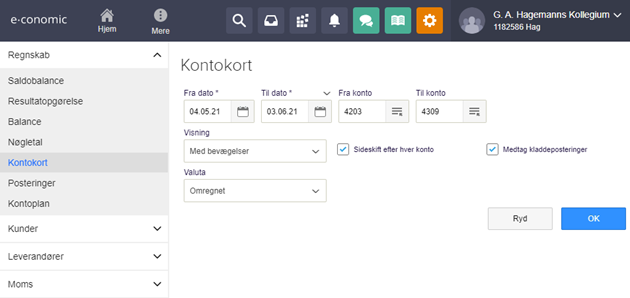

2. Gem til i følgende navn "1182586 - G. A. Hagemanns Kollegium"
3. Derfor skal contacts.txt rettes så rækkefølgen matcher med ovenstående PDF, udover det skal navnet være stavet identisk

4. kør de to nedenstående celler

In [2]:
def get_alumne_names(contacts_file):
    """
    Read names from contacts.txt (format: Name Email).
    Normalize hyphens to spaces.
    """
    names = []
    with open(contacts_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                raw_name = parts[0]
                normalized = raw_name.replace('-', ' ')  # e.g., "Ann-Sophie" → "Ann Sophie"
                names.append(normalized)
    print(f"[DEBUG] Loaded {len(names)} names from {contacts_file}: {names}")
    return names


def name_in_content(name, content):
    """Check if all parts of the name exist somewhere in the content (order-independent)."""
    name_tokens = name.lower().split()
    return all(token in content.lower() for token in name_tokens)


def filter_relevant_pages(pdf_path, contacts_file, output_path):
    """
    Creates a new PDF with only the pages that contain alumne names.
    Logs which names matched, and which didn't.
    """
    alumne_names = get_alumne_names(contacts_file)
    matched_names_set = set()
    reader = PdfReader(pdf_path)
    writer = PdfWriter()

    for i, page in enumerate(reader.pages):
        temp_filename = f'temp_page_{i+1}.pdf'
        writer_single = PdfWriter()
        writer_single.add_page(page)

        with open(temp_filename, 'wb') as f:
            writer_single.write(f)

        parsed = parser.from_file(temp_filename)
        content = parsed.get("content", "") or ""
        content = ' '.join(content.split())  # normalize whitespace
        os.remove(temp_filename)

        print(f"\n[DEBUG] Page {i+1} text:\n{content[:500]}...")

        matched_on_page = [name for name in alumne_names if name_in_content(name, content)]
        if matched_on_page:
            writer.add_page(page)
            matched_names_set.update(matched_on_page)
            print(f"[MATCH] Page {i+1} contains: {matched_on_page}")
        else:
            print(f"[SKIPPED] Page {i+1} — no matching alumne name.")

    if os.path.exists(output_path):
        print(f"[WARNING] Overwriting existing file: {output_path}")
        os.remove(output_path)

    with open(output_path, 'wb') as output_file:
        writer.write(output_file)
    print(f"\n[DONE] Saved filtered PDF as: {output_path}")

    unmatched_names = [name for name in alumne_names if name not in matched_names_set]
    print(f"\n[INFO] {len(unmatched_names)} names had no matches in the PDF:")
    for name in unmatched_names:
        print(f" - {name}")

In [3]:
filter_relevant_pages(
    pdf_path='1182586 - G. A. Hagemanns Kollegium.pdf',
    contacts_file='contacts.txt',
    output_path='1182586 - G. A. Hagemanns Kollegium_filtered.pdf'
)

[DEBUG] Loaded 61 names from contacts.txt: ['Magnus Guldberg Pedersen', 'Sophia Helena Andersen', 'Kamma Dyhr', 'Carla Zdravkovic Hugod', 'Adam Sjøqvist', 'Rose Reebirk Søltoft', 'Anton Mosquera Storgaard', 'Asta Vagnsø', 'Frederik Konner Lautrup Nielsen', 'Rosemarie Winther Goodchild', 'Anton Claes Pallavicini', 'Bjarke Jørn Kristensen', 'Sif Hommelgaard Sørensen', 'Emily Ahler Tonsberg', 'Thomas Bjørka Fosgaard', 'Olivia Gry Groth Hede', 'Carl Kjølby', 'Alma Klara Aagaard Darre', 'Louise Mathilde Bjerring Kastrup', 'Victor Bohart', 'Thea Klit', 'Emil Johannes Gantzel Gungaard', 'Laurits Fog Balstrup', 'Ann Sophie Dalby Andersen', 'Gustav Viborg Krarup Skovsager', 'Ofelia Fischer Godske', 'Aske Kjeldsen', 'Vebjørn Søberg', 'Carl Andersen', 'Bjarni Olsen', 'Joachim Nymand Klemensen', 'Niels Christian Jakobsen', 'Elnaz Vossoughi', 'Michelle Kramer Hendriksen', 'Charlotte Schrøder Jensen', 'Julian Sylvester Ryhne Rohland', 'Oliver Vincents', 'Amanda Schriver Mårtensson', 'Sofie Bay Nøste

5. Tjek nederste debug linje "[INFO] 0 names had no matches in the PDF:". Hvis dette står så er de unødvendige pdf sider blevet frafiltreret. Der skal også stå "[DEBUG] Loaded 61 names from contacts.txt". Da der er 61 alumner på kollegiet

6. Nu splittes "1182586 - G. A. Hagemanns Kollegium_filtered.pdf" til 61 seperate pdf'er

In [4]:
# Open and split the PDF into individual pages as separate files

pdf_path = '1182586 - G. A. Hagemanns Kollegium_filtered.pdf'

with open(pdf_path, 'rb') as pdf_file:
    pdf_reader = PdfReader(pdf_file)
    pageNumbers = len(pdf_reader.pages)

    for i in range(pageNumbers):
        pdf_writer = PdfWriter()
        pdf_writer.add_page(pdf_reader.pages[i])
        output_filename = f"{i+1}.pdf"
        with open(output_filename, 'wb') as split_file:
            pdf_writer.write(split_file)

print(f"Split {pageNumbers} pages into individual PDF files.")

Split 61 pages into individual PDF files.


7. Kør nedenstående 2 celler - nederste celle sender mails ud

In [5]:
def send_emails():
    # Read contacts and template
    names, emails = get_contacts('contacts.txt')
    message_template = read_template('message.txt')
    file_names = get_filenames(names)

    # Setup SMTP server
    s = smtplib.SMTP(host='smtp.gmail.com', port=587)
    s.starttls()
    login, password = 'RegnskabGAHK@gmail.com', 'xtioqqoypowwdsyd'
    s.login(login, password)

    # Rename pdf files from numbers to names, and check first names exist in PDF content
    for filename in file_names:
        k = int(filename) - 1  # index
        raw_text = parser.from_file(filename + ".pdf")['content']
        Split_Name = names[k].split('-')
        First_Name = Split_Name[0]
        if First_Name not in raw_text:
            print(f"Error at row {k}, First name '{First_Name}' not found in PDF text!")
            # Instead of sys.exit, just raise an error or continue as you prefer
            raise ValueError(f"Name mismatch: {First_Name} not found in PDF {filename}.pdf")
        os.rename(filename + ".pdf", names[k] + ".pdf")

    # Send emails
    for name, email in zip(names, emails):
        msg = MIMEMultipart()
        message = message_template.substitute(PERSON_NAME=name.title())
        print(f"Sending to: {name.title()} <{email}>")
        print(message)

        msg['From'] = 'Regnskabsgruppen'
        msg['To'] = email
        msg['Subject'] = 'Alumneregning'

        msg.attach(MIMEText(message, 'plain'))

        with open(name + ".pdf", 'rb') as regning_pdf:
            part1 = MIMEApplication(regning_pdf.read(), Name=basename(name + ".pdf"))
        part1['Content-Disposition'] = f'attachment; filename="{basename(name + ".pdf")}"'
        msg.attach(part1)

        with open('følgebrev.pdf', 'rb') as skabelon:
            part2 = MIMEApplication(skabelon.read(), Name=basename('følgebrev.pdf'))
        part2['Content-Disposition'] = f'attachment; filename="{basename("følgebrev.pdf")}"'
        msg.attach(part2)

        s.send_message(msg)
        del msg

    s.quit()
    print("All emails sent successfully.")

In [6]:
send_emails()

Sending to: Magnus-Guldberg-Pedersen <Magnusguldberg@live.dk>
Hej Magnus-Guldberg-Pedersen

Os i Regnskabsgruppen sender dig hermed (vedhæftet) din alumneregning for den forgangne måned.

Vi beder om at du generelt forsøger at holde din gæld så lav som muligt.

Hvis du skylder mere end 600 kr. beder vi om at du indbetaler inden for udgangen af indeværende uge.
Skulle du have brug for en speciel aftale om afbetaling, fordi din gæld er for stor til, at du kan betale den
af på én gang, så bedes du kontakte det siddende inspektionsmedlem i Regnskabsgruppen.

Det nederste tal i søjlen til højre under ”saldo” er din gæld til kollegiet. Hvis beløbet er negativt skylder kollegiet dig penge.

UDFLYTTER-INFO: Denne regning skal ikke betales. 
I tilfælde af at du skylder alumnekassen penge bliver dette fratrukket dit depositum som PKS tilbagebetaler snarest. 

------------------------------------------------------------------------

På Vegne af Regnskabsgruppen på G. A. Hagemanns Kollegium

Reg. 

8. Lav en stikprøve kontrol af en af dine regnskabsvenner om at de har modtaget mail, samt det korrekte beløb er vedhæftet i pdf
9. Hvis ikke det giver mening så snak med Victor Bohart eller Emil Gantzel Gungaard 